### Load packages

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle, json, io
import importlib
import cf_search.visualize
importlib.reload(cf_search.visualize)

# Now re-import your function
from cf_search.visualize import plot_cf_kde_cell


from cf_search.visualize import (
    extract_cell_data,
    plot_counterfactuals,
    plot_fitness_heatmap,
    plot_all_pcas_grid,
    plot_all_pcas_grid_by_cluster,
    plot_all_clusters_by_heatmap,
    plot_all_mutable_clusters_by_heatmap,
    plot_cf_clustermap_cell,
    plot_cf_umap_cell,
    plot_cf_eta2_bar_cell,
    plot_cf_meanvalue_heatmap_cell,
    plot_cf_kde_cell,
    plot_cellwise_grid,
    plot_cf_meanvalue_heatmap_constraints_cell,
    plot_cf_eta2_bar_constraints_cell,
    tree_constraints_to_cluster_kmeans,
    tree_constraints_to_hclust_cell,
    correlation_heatmap_cell,
    correlation_mutable_vs_constraint_cell,
    plot_by_cluster
)

### Load data

In [15]:
# Update paths accordingly
output_dir = "synthetic/mlp_model_uniform_init5000_iter50000_paper"
#output_dir = "synthetic/perfect_model_uniform_init5000_iter10000" #ground truth model
archive_path = f'{output_dir}/counterfactuals.pkl'
feature_json_path = 'synthetic/synthetic_feature_categories_action.json' # use synthetic_feature_categories.json for multiple categories, synthetic_feature_categories_action.json for actionability categories

with open(archive_path, 'rb') as f:
    archive_data = pickle.load(f)

with open(feature_json_path, 'r') as f:
    feature_categories = json.load(f)

category_labels = list(feature_categories.keys())
num_categories = len(category_labels)

cell_feature_sets = {
    (i, j): feature_categories[category_labels[i]] + (feature_categories[category_labels[j]] if i != j else [])
    for i in range(num_categories)
    for j in range(num_categories)
}


### View data for a specific cell

In [42]:
i, j = 0,0  # Change as needed
cell_df = extract_cell_data(archive_data, (i, j))

print(f"Found {len(cell_df)} counterfactuals in cell ({i}, {j})")

Found 200 counterfactuals in cell (0, 0)


### Grid plots

#### Combined subplots

In [9]:
ref_df = pd.read_csv("synthetic/synthetic_test.csv")#.drop(columns="Unnamed: 0")  # Optional reference individuals
color_feature = "fitness"
max_k = 8
cluster_method="kmeans"
reducer="PCA"

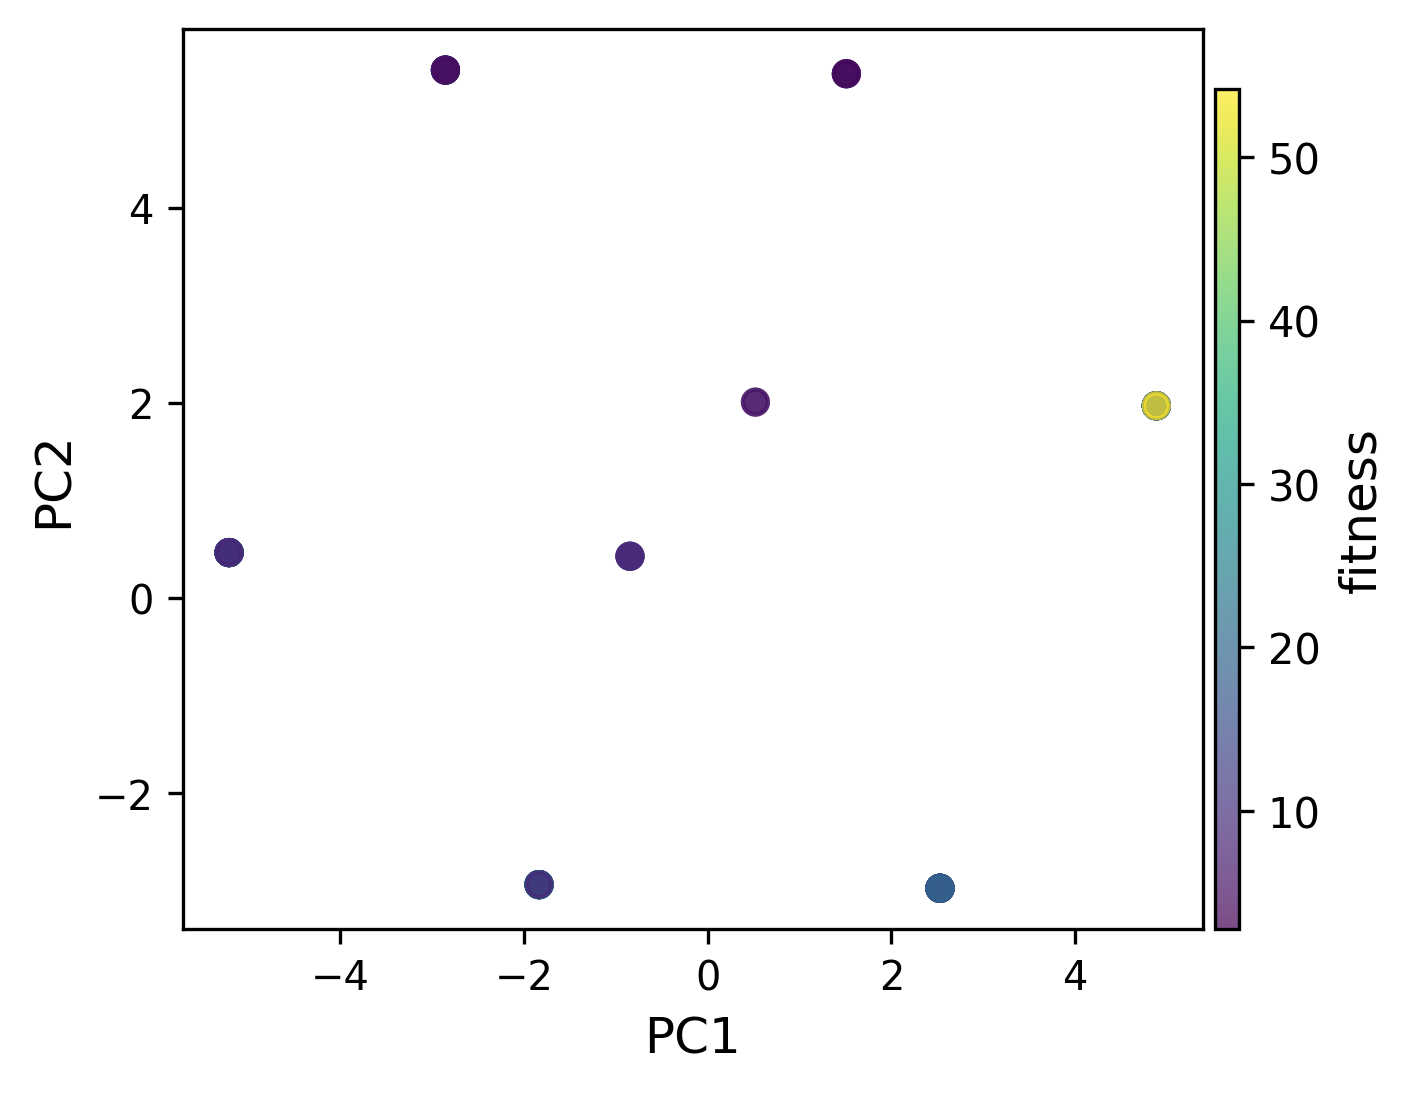

In [4]:

# Compute global vmin/vmax
all_vals = []
for cell_key in cell_feature_sets:
    df = extract_cell_data(archive_data, cell_key)
    if color_feature in df.columns:
        all_vals.extend(df[color_feature].dropna().tolist())

vmin, vmax = min(all_vals), max(all_vals)

fig_ = plot_cellwise_grid(
    archive_data,
    cell_feature_sets,
    feature_categories,
    plot_counterfactuals,
    plot_type_name="PCA of Counterfactuals",
    color_feature=color_feature,
    global_vmin=vmin,
    global_vmax=vmax,
    wspace = 0.5,
    figsize_per_cell=(4, 4),
    rowlabel_offset=-0.5,
    colorbar_label=color_feature,
    fontsize=12,
    colorbar=True,
    colorbar_fontsize=12,
    scale=False
)
figA = plot_cellwise_grid(
    archive_data,
    cell_feature_sets,
    feature_categories,
    plot_by_cluster,
    plot_type_name="PCA of Counterfactuals",
    wspace = 0.5,
    figsize_per_cell=(5, 5),
    cluster_method=cluster_method,
    reducer=reducer,
    max_k=max_k,
    cluster_legend=False,
    scale=False
)
figA.savefig("PCA.png", bbox_inches="tight")

figB = plot_cellwise_grid(
    archive_data,
    cell_feature_sets,
    feature_categories,
    plot_cf_eta2_bar_cell,
    plot_type_name="η² for Mutable Features",
    figsize_per_cell=(3, 3.75),
    rowlabel_offset=0,
    wspace=0.8,
    hspace=0.3,
    cluster_method=cluster_method,
    reducer=reducer,
    max_k=max_k,
    top_n=10,
    draw_threshold=False
)
figB.savefig("eta_mutable.png", bbox_inches="tight")


figC = plot_cellwise_grid(
    archive_data,
    cell_feature_sets,
    feature_categories,
    plot_cf_eta2_bar_constraints_cell,
    plot_type_name="η² for Constraint Features",
    figsize_per_cell=(3, 3.25),
    rowlabel_offset=0,
    wspace=0.8,
    hspace=0.3,
    cluster_method=cluster_method,
    reducer=reducer,
    max_k=max_k,
    top_n=10,
    fontsize=16,
    draw_threshold=False
)
figC.savefig("eta_constraint.png", bbox_inches="tight")

# Generate and save each grid figure
figD = plot_cellwise_grid(
    archive_data,
    cell_feature_sets,
    feature_categories,
    plot_cf_meanvalue_heatmap_cell,
    plot_type_name="Mutable",
    figsize_per_cell=(5, 4),
    cluster_method=cluster_method,
    reducer=reducer,
    rowlabel_offset=0.1,
    max_k=max_k,
    fontsize=18
)
figD.savefig("grid_mutable.png", bbox_inches="tight")

figE = plot_cellwise_grid(
    archive_data,
    cell_feature_sets,
    feature_categories,
    plot_cf_meanvalue_heatmap_constraints_cell,
    plot_type_name="Constraint",
    figsize_per_cell=(5, 4),
    cluster_method=cluster_method,
    reducer=reducer,
    rowlabel_offset=0.1,
    max_k=max_k,
    fontsize=17
)
figE.savefig("grid_constraint.png", bbox_inches="tight")

plt.close(figA)
plt.close(figB)
plt.close(figD)
plt.close(figC)
plt.close(figE)


import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from PIL import Image
import numpy as np

# Load images
imgA = np.array(Image.open("PCA.png"))
img1 = np.array(Image.open("eta_mutable.png"))
img2 = np.array(Image.open("eta_constraint.png"))
img3 = np.array(Image.open("grid_mutable.png"))
img4 = np.array(Image.open("grid_constraint.png"))

# Create figure
fig = plt.figure(figsize=(20, 12), dpi=1000)

# Outer grid
gs = GridSpec(
    2, 1,
    height_ratios=[1, 1],
    hspace=0.0,
    figure=fig
)

# ------------------------
# Top row (A, B, C)
# ------------------------
gs_top = gs[0].subgridspec(
    1, 3,
    width_ratios=[1, 1, 1],
    wspace=0.05
)

axA = fig.add_subplot(gs_top[0, 0])
axB = fig.add_subplot(gs_top[0, 1])
axC = fig.add_subplot(gs_top[0, 2])

axA.imshow(imgA)
axB.imshow(img1)
axC.imshow(img2)

axA.axis("off")
axB.axis("off")
axC.axis("off")


# Panel labels (tweak coordinates if needed)
axA.text(0.01, 1.04, "A", transform=axA.transAxes,
         fontsize=22, fontweight="bold", ha="left", va="top")

axB.text(0.02, 1.02, "B", transform=axB.transAxes,
         fontsize=22, fontweight="bold", ha="left", va="top")

axC.text(0.02, 1.01, "C", transform=axC.transAxes,
         fontsize=22, fontweight="bold", ha="left", va="top")

# ------------------------
# Bottom row (D, E)
# ------------------------
gs_bottom = gs[1].subgridspec(
    1, 2,
    wspace=0.05
)

axD = fig.add_subplot(gs_bottom[0, 0])
axE = fig.add_subplot(gs_bottom[0, 1])

axD.imshow(img3)
axE.imshow(img4)

axD.axis("off")
axE.axis("off")

# Panel labels
axD.text(0.01, 0.99, "D", transform=axD.transAxes,
         fontsize=22, fontweight="bold", ha="left", va="top")

axE.text(0.01, 0.99, "E", transform=axE.transAxes,
         fontsize=22, fontweight="bold", ha="left", va="top")

# Final spacing tweaks
plt.subplots_adjust(
    left=0.02,
    right=0.99,
    top=0.98,
    bottom=0.02,
    hspace=0.0
)

plt.show()

/global/home/hpc5434/.local/lib/python3.11/site-packages/matplotlib/collections.py:1109: UserWarning: Collection without array used. Make sure to specify the values to be colormapped via the `c` argument.
  warnings.warn("Collection without array used. Make sure to "
/global/home/hpc5434/COALA/cf_search/visualize.py:340: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(


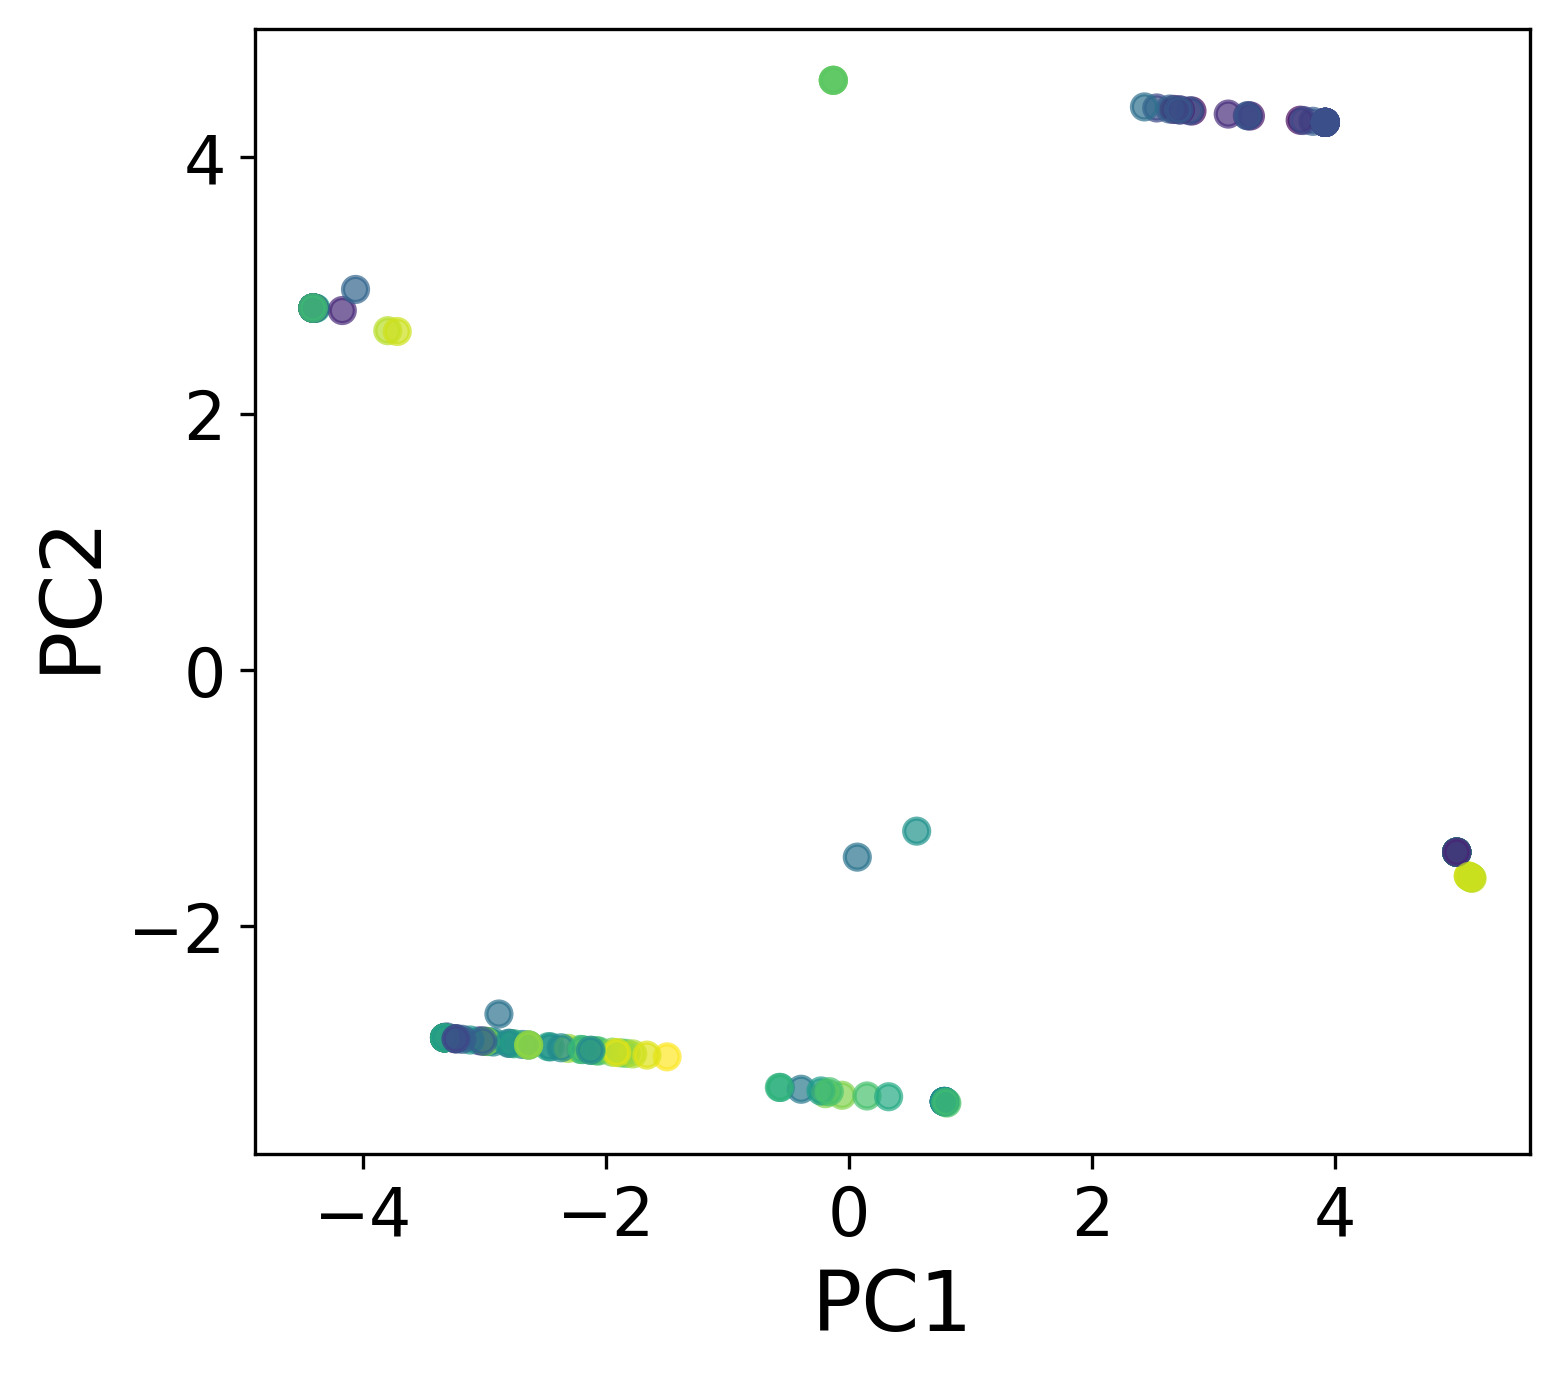

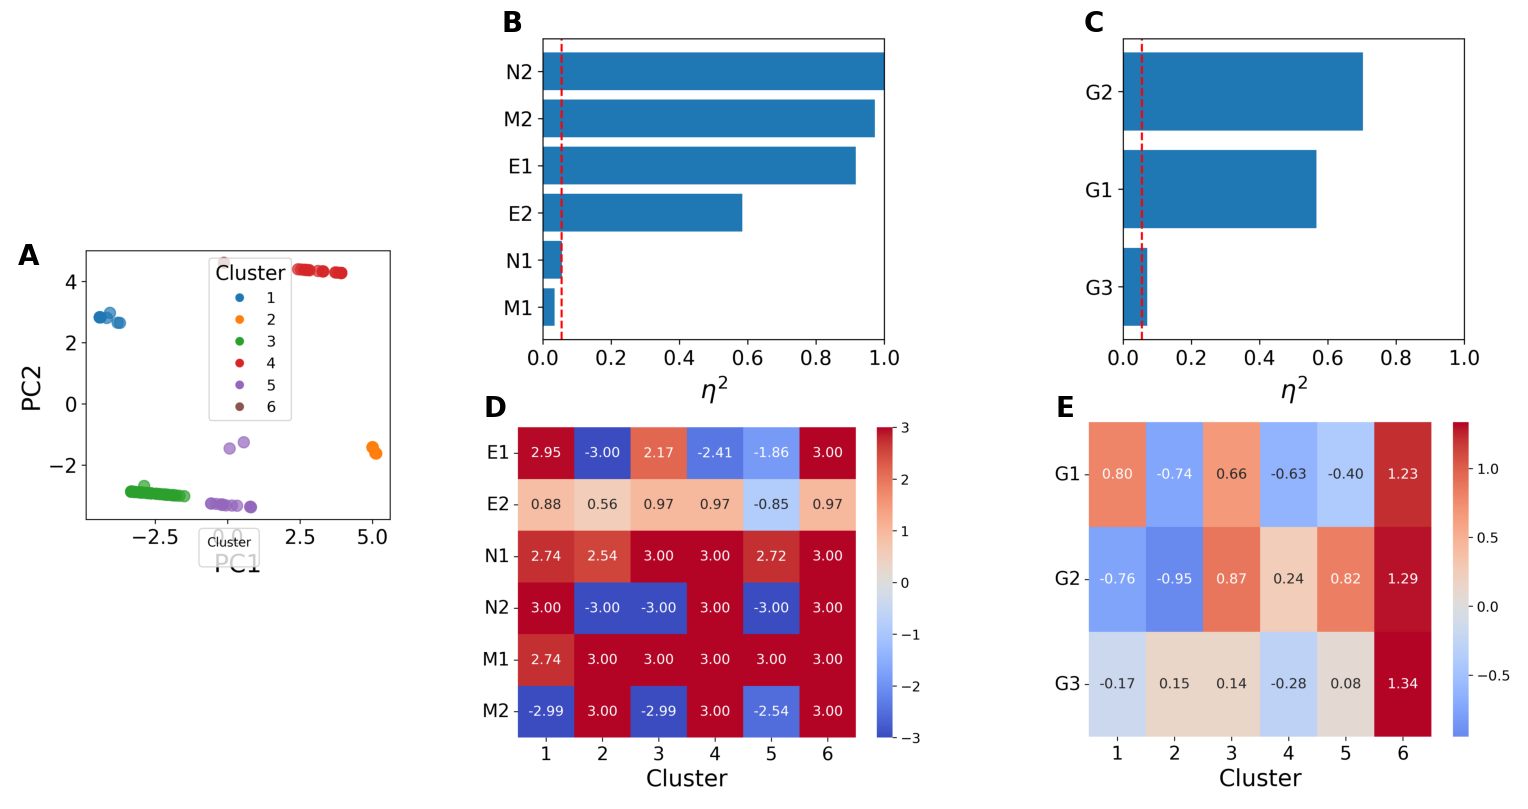

In [16]:
ref_df = pd.read_csv("synthetic/synthetic_test.csv")#.drop(columns="Unnamed: 0")  # Optional reference individuals
color_feature = "fitness"
max_k = 8
cluster_method="kmeans"
reducer="PCA"

# Optional: add ref_df values into archive_data
'''
for key, df in archive_data.items():
    if key < len(ref_df):
        archive_data[key][color_feature] = ref_df.iloc[key][color_feature]
'''
# Compute global vmin/vmax
all_vals = []
for cell_key in cell_feature_sets:
    df = extract_cell_data(archive_data, cell_key)
    if color_feature in df.columns:
        all_vals.extend(df[color_feature].dropna().tolist())

vmin, vmax = min(all_vals), max(all_vals)

fig_ = plot_cellwise_grid(
    archive_data,
    cell_feature_sets,
    feature_categories,
    plot_counterfactuals,
    plot_type_name="PCA of Counterfactuals",
    color_feature=color_feature,
    global_vmin=vmin,
    global_vmax=vmax,
    figsize_per_cell=(5, 5),
    colorbar_label=color_feature, scale=False
)
figA = plot_cellwise_grid(
    archive_data,
    cell_feature_sets,
    feature_categories,
    plot_by_cluster,
    plot_type_name="PCA of Counterfactuals",
    #color_feature=color_feature,
    #global_vmin=vmin,
    #global_vmax=vmax,
    figsize_per_cell=(4, 4),
    cluster_method=cluster_method,
    reducer=reducer,
    max_k=max_k,
    legend=True,
    scale=False #
)
figA.savefig("PCA.png", bbox_inches="tight")

figB = plot_cellwise_grid(
    archive_data,
    cell_feature_sets,
    feature_categories,
    plot_cf_eta2_bar_cell,
    plot_type_name="η² for Mutable Features",
    figsize_per_cell=(4, 4),
    cluster_method=cluster_method,
    reducer=reducer,
    max_k=max_k
)
figB.savefig("eta_mutable.png", bbox_inches="tight")


figC = plot_cellwise_grid(
    archive_data,
    cell_feature_sets,
    feature_categories,
    plot_cf_eta2_bar_constraints_cell,
    plot_type_name="η² for Constraint Features",
    figsize_per_cell=(4, 4),
    cluster_method=cluster_method,
    reducer=reducer,
    max_k=max_k
)
figC.savefig("eta_constraint.png", bbox_inches="tight")

# Generate and save each grid figure
figD = plot_cellwise_grid(
    archive_data,
    cell_feature_sets,
    feature_categories,
    plot_cf_meanvalue_heatmap_cell,
    plot_type_name="Mutable",
    figsize_per_cell=(6, 5),
    cluster_method=cluster_method,
    reducer=reducer,
    max_k=max_k
)
figD.savefig("grid_mutable.png", bbox_inches="tight")

figE = plot_cellwise_grid(
    archive_data,
    cell_feature_sets,
    feature_categories,
    plot_cf_meanvalue_heatmap_constraints_cell,
    plot_type_name="Constraint",
    figsize_per_cell=(6, 5),
    cluster_method=cluster_method,
    reducer=reducer,
    max_k=max_k
)
figE.savefig("grid_constraint.png", bbox_inches="tight")

plt.close(figA)
plt.close(figB)
plt.close(figD)
plt.close(figC)
plt.close(figE)

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from PIL import Image
import numpy as np

# Load images
imgA = np.array(Image.open("PCA.png"))
img1 = np.array(Image.open("eta_mutable.png"))
img2 = np.array(Image.open("eta_constraint.png"))
img3 = np.array(Image.open("grid_mutable.png"))
img4 = np.array(Image.open("grid_constraint.png"))

# Create figure and grid layout
fig = plt.figure(figsize=(20, 10))
gs = GridSpec(2, 3, figure=fig, width_ratios=[0.7, 1, 1]) 
plt.subplots_adjust(wspace=0.05, hspace=0.0)

# Big PCA plot on the left (A)
axA = fig.add_subplot(gs[:, 0])
axA.imshow(imgA)
axA.axis('off')
axA.text(0.02, 1, "A", transform=axA.transAxes, fontsize=20, fontweight='bold', va='top')
axA.set_xlabel("PC1", fontsize=14)
axA.set_ylabel("PC2", fontsize=14)

# Small plots on the right (B–E)
axB = fig.add_subplot(gs[0, 1])
axB.imshow(img1)
axB.axis('off')
axB.text(0.02, 1.05, "B", transform=axB.transAxes, fontsize=20, fontweight='bold', va='top')

axC = fig.add_subplot(gs[0, 2])
axC.imshow(img2)
axC.axis('off')
axC.text(0.02, 1.05, "C", transform=axC.transAxes, fontsize=20, fontweight='bold', va='top')

axD = fig.add_subplot(gs[1, 1])
axD.imshow(img3)
axD.axis('off')
axD.text(0.02, 1.05, "D", transform=axD.transAxes, fontsize=20, fontweight='bold', va='top')

axE = fig.add_subplot(gs[1, 2])
axE.imshow(img4)
axE.axis('off')
axE.text(0.02, 1.05, "E", transform=axE.transAxes, fontsize=20, fontweight='bold', va='top')

plt.show()


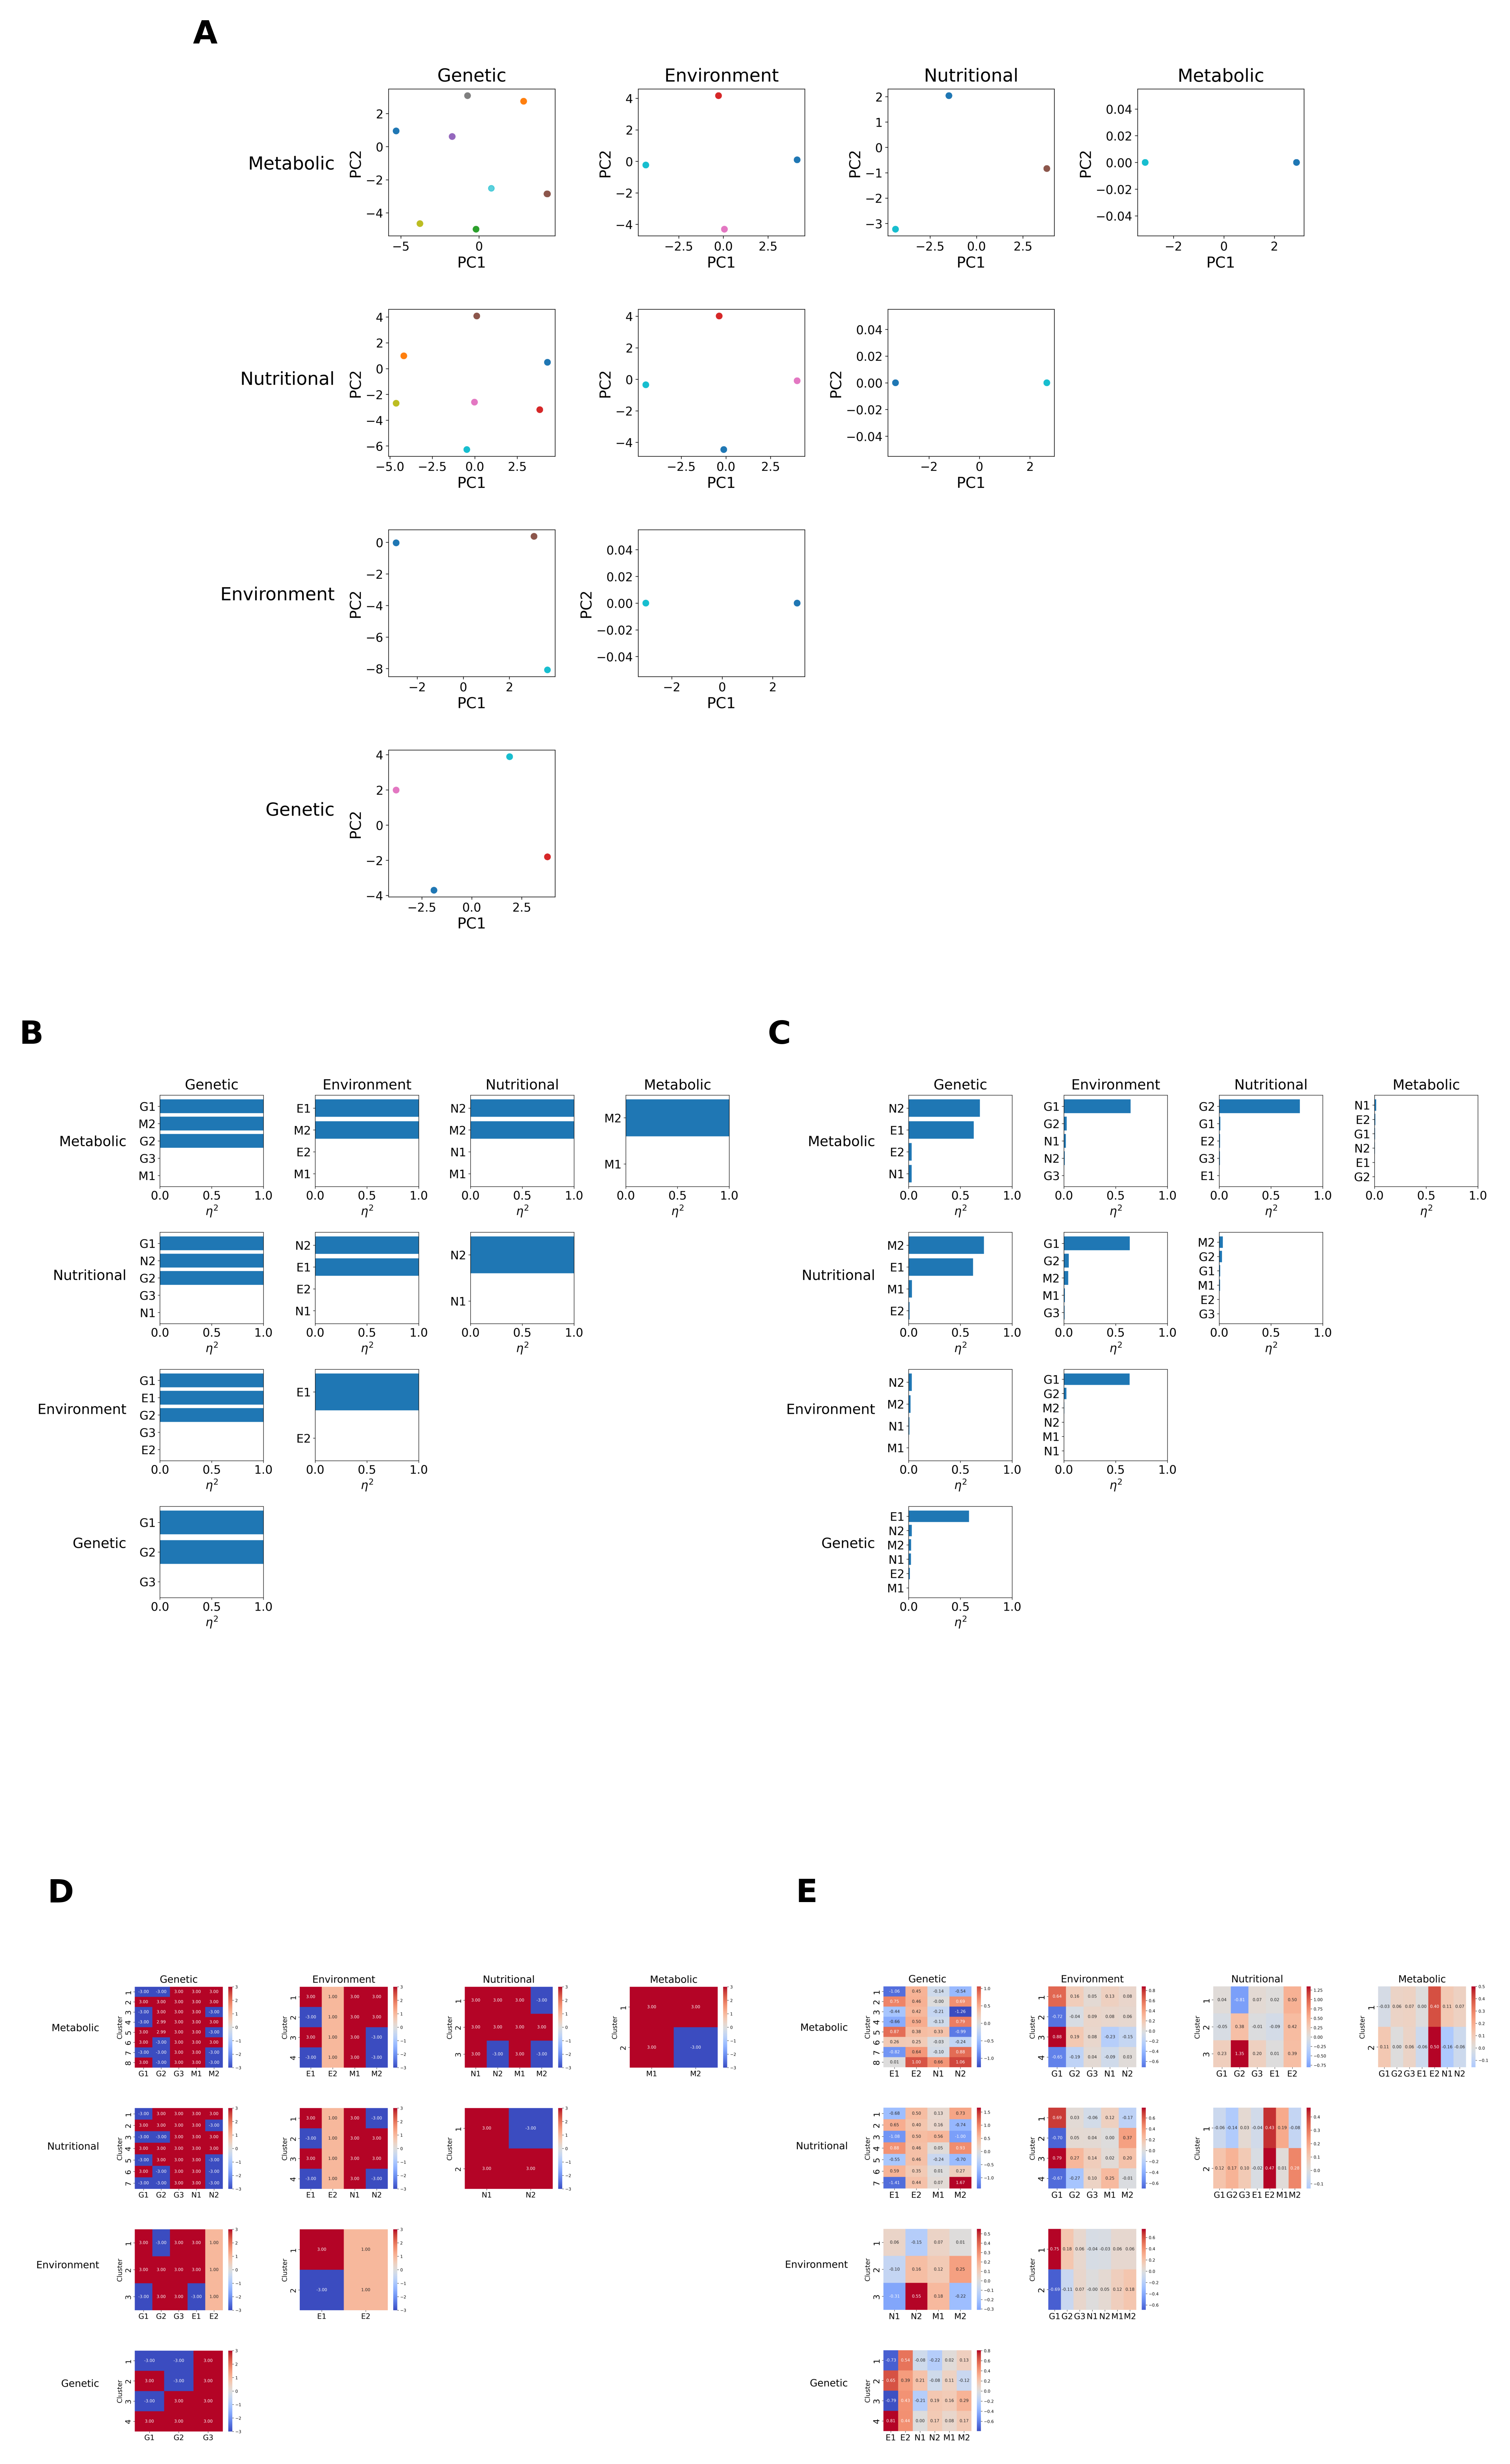

In [15]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(8, 14), dpi=500)

# 3 rows: A (top row), B–E (2×2 grid below)
gs = GridSpec(3, 2, figure=fig, height_ratios=[1, 1, 1])  # A gets more height

# Plot A on top, spanning both columns
axA = fig.add_subplot(gs[0, :])
axA.imshow(imgA)
axA.axis('off')
axA.text(-0.02, 1.05, "A", transform=axA.transAxes, fontsize=12, fontweight='bold', va='top')
axA.set_xlabel("PC1", fontsize=14)
axA.set_ylabel("PC2", fontsize=14)

# Plots B–E in a 2x2 grid below A
axB = fig.add_subplot(gs[1, 0])
axB.imshow(img1)
axB.axis('off')
axB.text(-0.02, 1.1, "B", transform=axB.transAxes, fontsize=12, fontweight='bold', va='top')

axC = fig.add_subplot(gs[1, 1])
axC.imshow(img2)
axC.axis('off')
axC.text(-0.02, 1.1, "C", transform=axC.transAxes, fontsize=12, fontweight='bold', va='top')

axD = fig.add_subplot(gs[2, 0])
axD.imshow(img3)
axD.axis('off')
axD.text(0.02, 1.2, "D", transform=axD.transAxes, fontsize=12, fontweight='bold', va='top')

axE = fig.add_subplot(gs[2, 1])
axE.imshow(img4)
axE.axis('off')
axE.text(0.02, 1.2, "E", transform=axE.transAxes, fontsize=12, fontweight='bold', va='top')

plt.tight_layout()
plt.show()


#### Decision trees

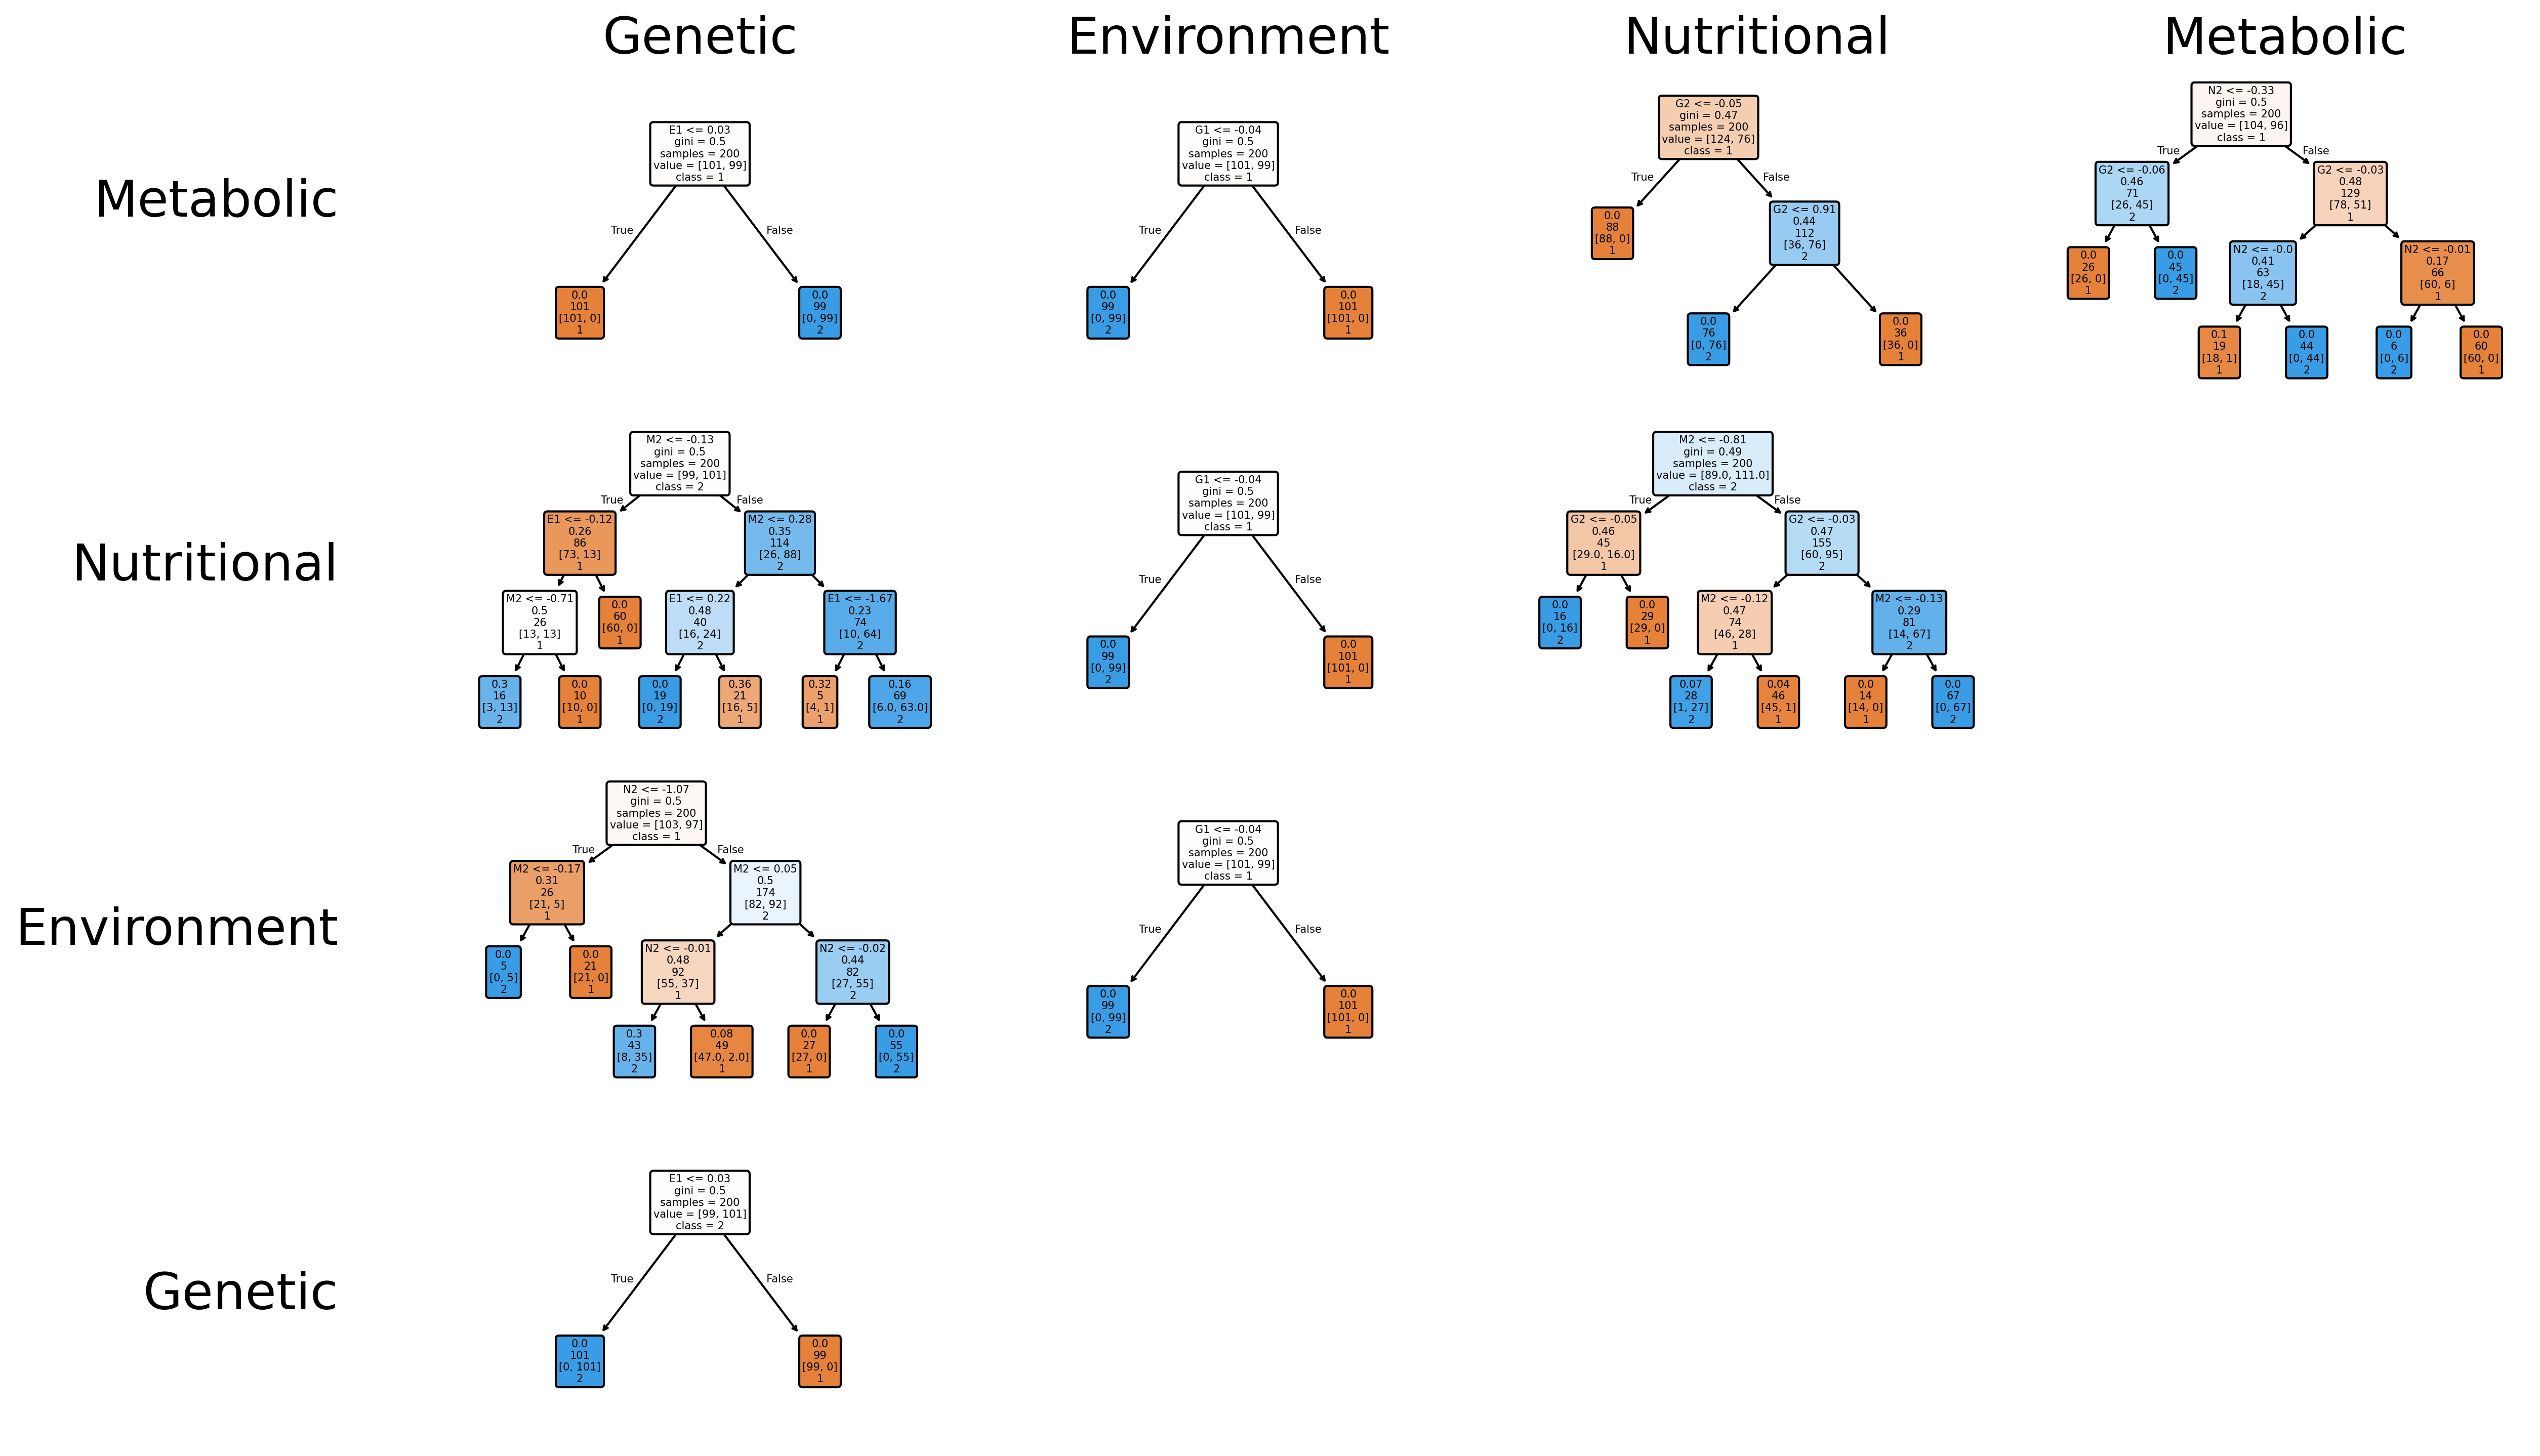

In [5]:
fig_ = plot_cellwise_grid(
    archive_data,
    cell_feature_sets,
    feature_categories,
    tree_constraints_to_cluster_kmeans,
    plot_type_name="PCA of Counterfactuals",
    figsize_per_cell=(4, 3),
    hspace=0.1,
    wspace=0.1,
    max_k=2,
    max_depth=3
 
)

#### Eta bar plots

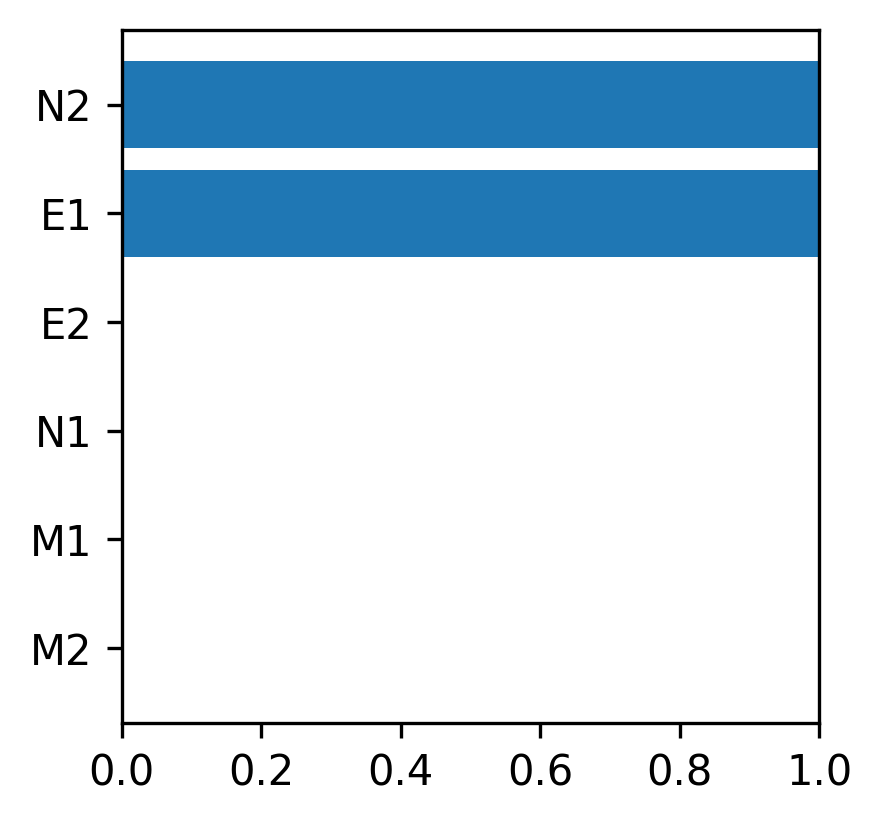

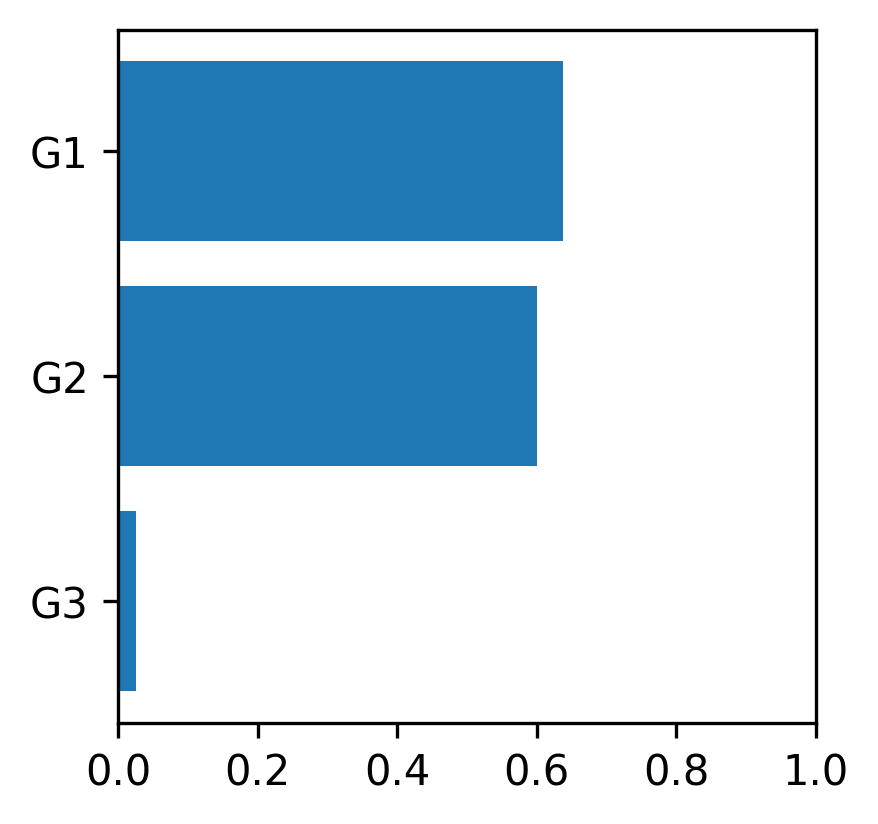

In [119]:
fig = plot_cellwise_grid(
    archive_data,
    cell_feature_sets,
    feature_categories,
    plot_cf_eta2_bar_cell,
    plot_type_name="η² for Mutable Features",
    figsize_per_cell=(3, 3)
)
plt.show()

fig = plot_cellwise_grid(
    archive_data,
    cell_feature_sets,
    feature_categories,
    plot_cf_eta2_bar_constraints_cell,
    plot_type_name="η² for Constraint Features",
    figsize_per_cell=(3, 3)
)
plt.show()


#### Heatmap of means

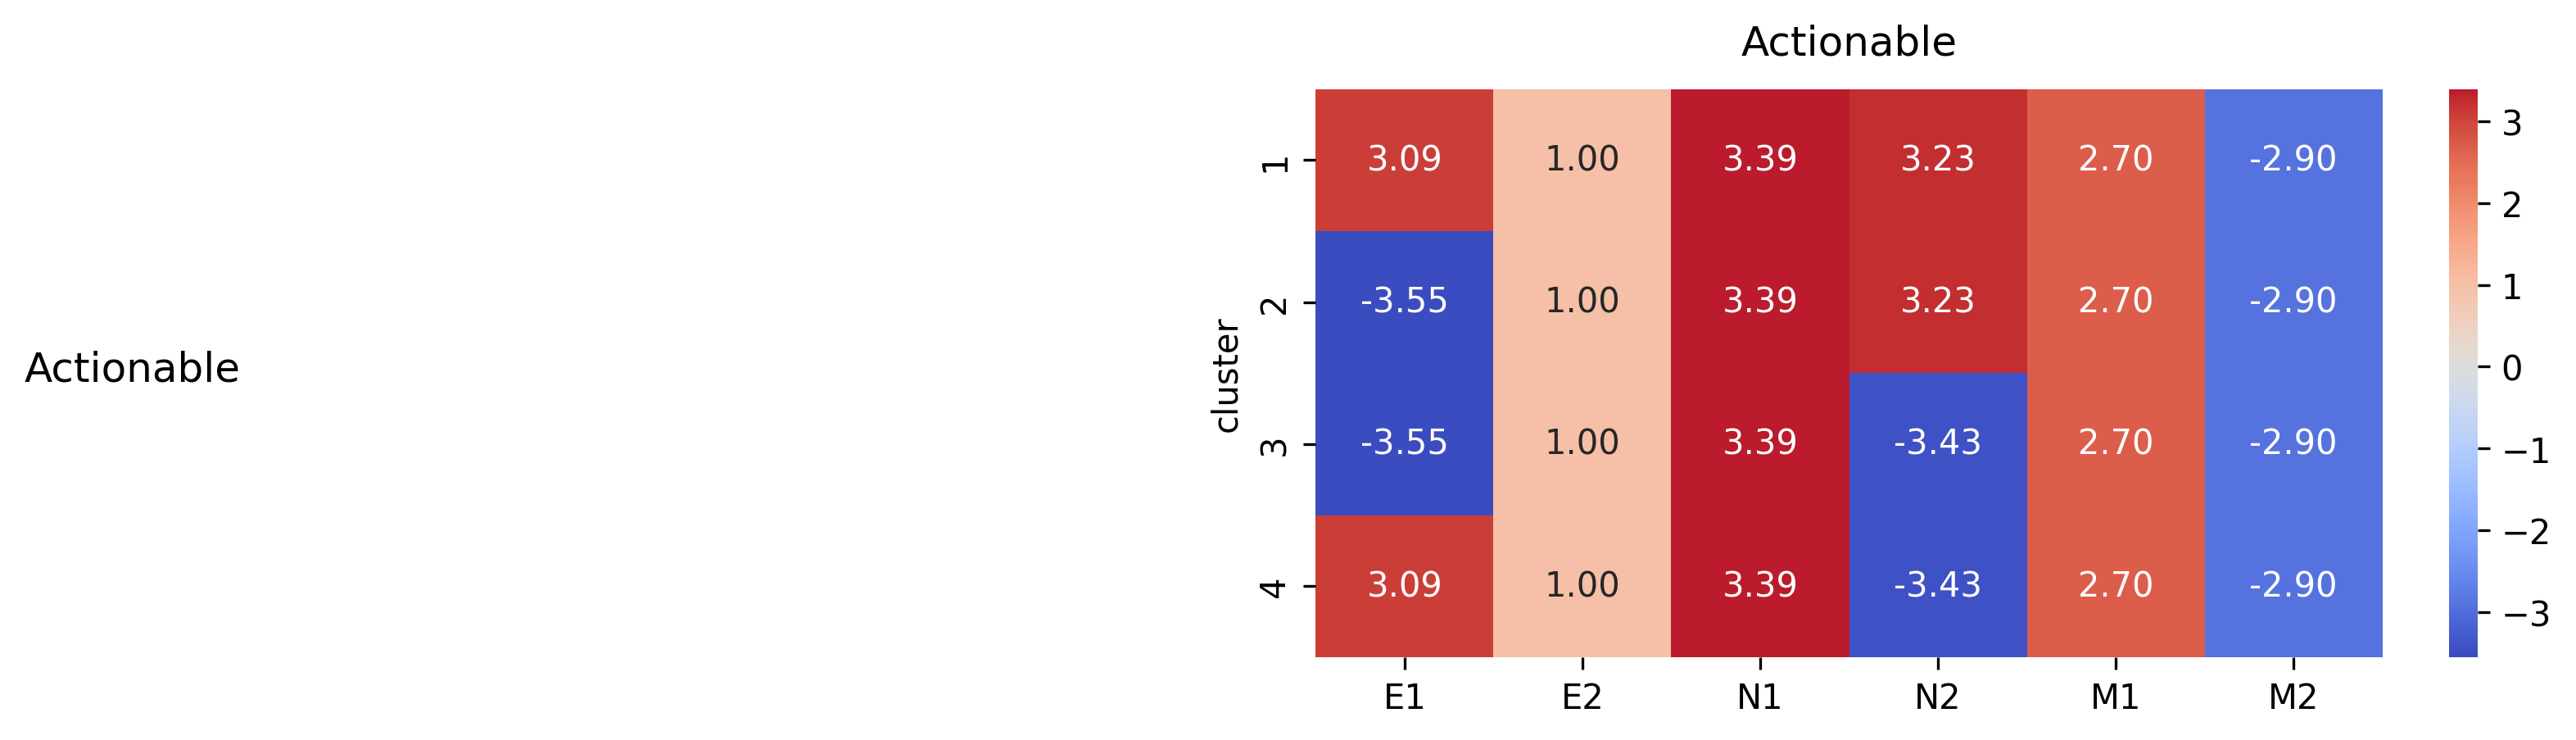

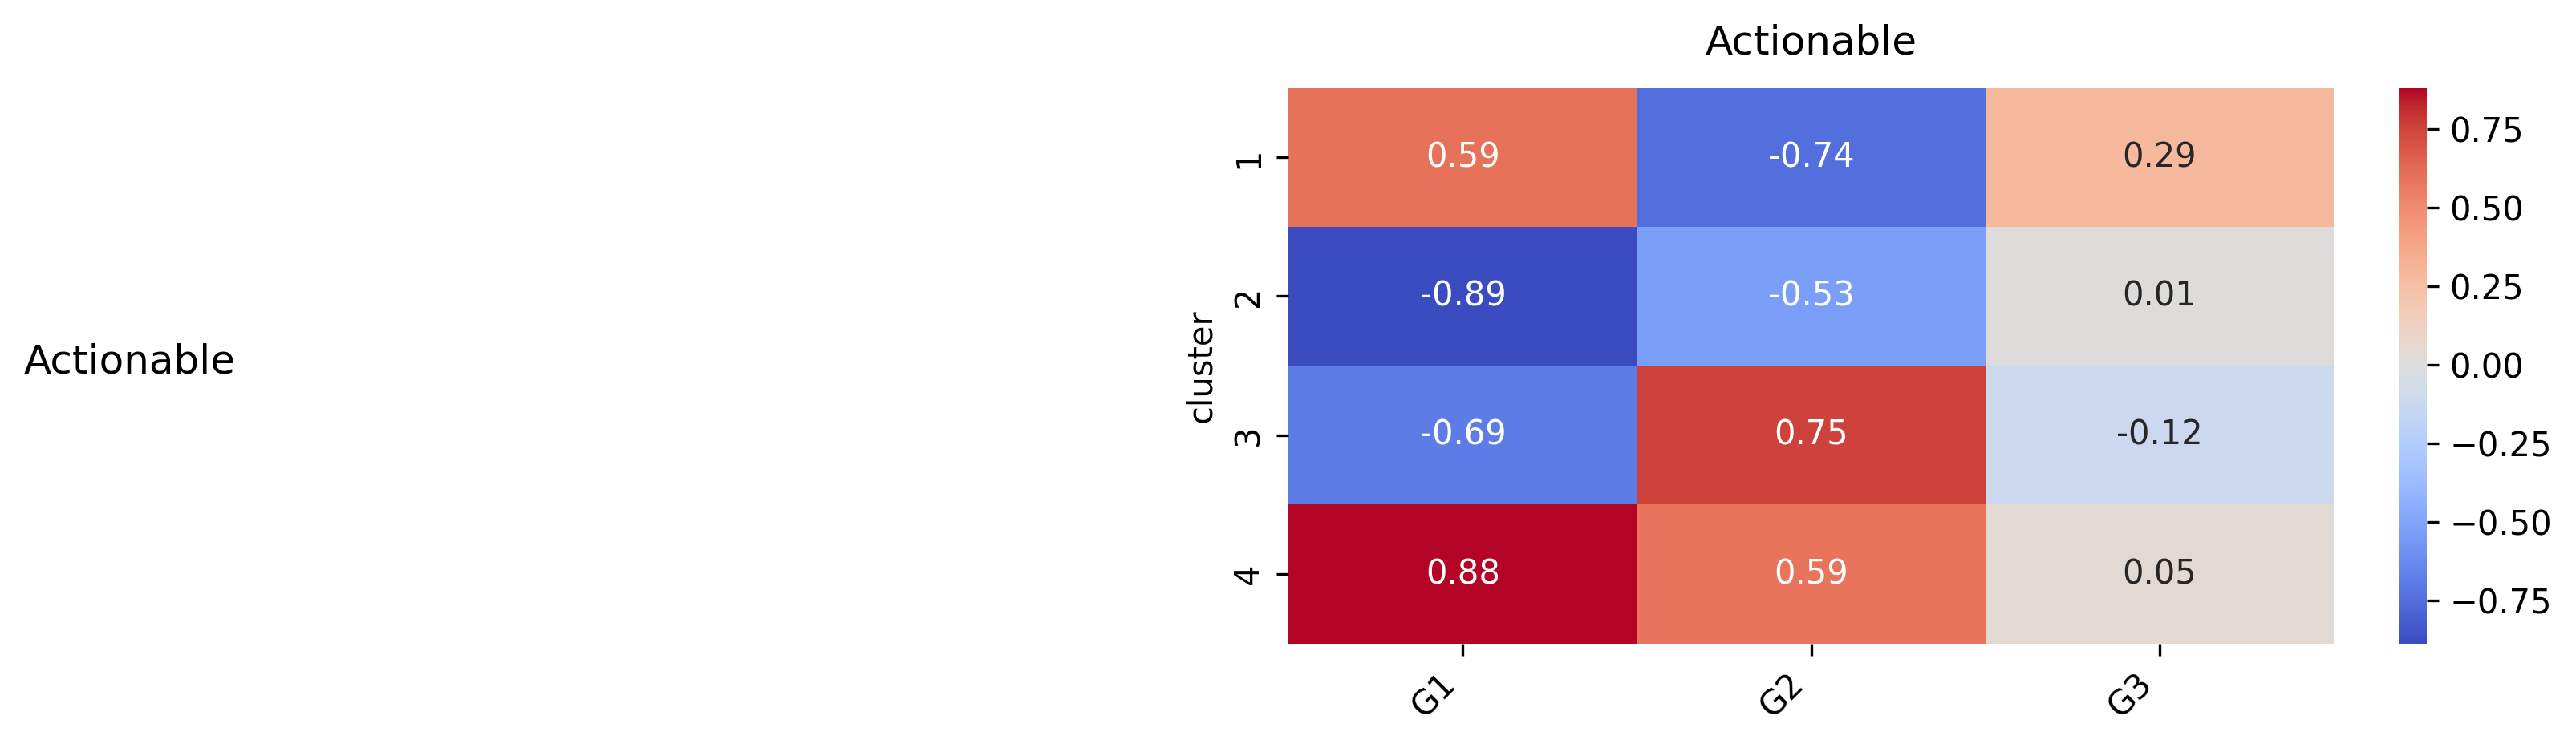

In [6]:
fig = plot_cellwise_grid(
    archive_data,
    cell_feature_sets,
    feature_categories,
    plot_cf_meanvalue_heatmap_cell,
    plot_type_name="Mean Values per Cluster (Mutable)",  # or any other number of clusters you'd like to use
    figsize_per_cell=(7, 3)
)
plt.show()


fig = plot_cellwise_grid(
    archive_data,
    cell_feature_sets,
    feature_categories,
    plot_cf_meanvalue_heatmap_constraints_cell,
    plot_type_name="Mean Values per Cluster (Constraint)",
    figsize_per_cell=(7, 3)
)
plt.show()


### SHAP

#### load models

In [ ]:
import torch.nn as nn
import torch
import shap
import pandas as pd
import matplotlib.pyplot as plt

class MyModel(nn.Module):
    def __init__(self, input_dim):
        super(MyModel, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 160),# First hidden layer
            nn.Dropout(0.5), 
            nn.ReLU(),
            nn.Linear(160, 1)
        )
    def forward(self, x):
        return self.model(x)


class SimpleMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.Tanh(),
            nn.Linear(32, 16),
            #nn.Dropout(0.1),
            nn.Tanh(),
            nn.Linear(16, 16),
            nn.Tanh(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.model(x)

class PerfectWrapper:
    def __init__(self):
        # Define feature ordering if needed
        self.feature_names = ['G1', 'G2', 'G3', 'E1', 'E2', 'N1', 'N2', 'M1', 'M2']

    def predict(self, X):
        # If input is a DataFrame, convert to NumPy in correct order
        if hasattr(X, 'loc') or hasattr(X, 'iloc'):
            X = X[self.feature_names].values

        G1 = X[:, 0]
        G2 = X[:, 1]
        G3 = X[:, 2]
        E1 = X[:, 3]
        E2 = X[:, 4]
        N1 = X[:, 5]
        N2 = X[:, 6]
        M1 = X[:, 7]
        M2 = X[:, 8]

        y = (
            0.5 * G3 +
            0.7 * E2 +
            0.2 * N1 +
            0.3 * M1 +
            + 1.8 * G1 * E1 #interaction between 2 features
            + 1.8 * G2 * N2 * M2 # higher order interaction
        )
        return y
model_name="mlp_model"
model_path="synthetic/mlp_model.pkl"
X_train_df = pd.read_csv("synthetic/synthetic_train.csv").drop(columns="Unnamed: 0")

if model_path.endswith(".pth"):
    if model_name == "mlp_model":
        input_dim = X_train_df.shape[1]
        wrapper = SimpleMLP(input_dim)
        wrapper.load_state_dict(torch.load(model_path, map_location=torch.device("cpu")))
        wrapper.eval()
else:
    with open(model_path, "rb") as f:
        wrapper = pickle.load(f)  # sklearn model

#### Perfect model

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/200 [00:00<?, ?it/s]

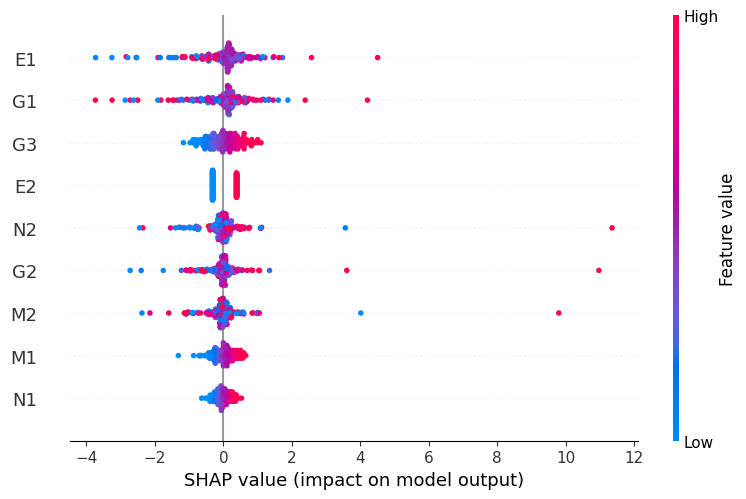

In [5]:


# Load your trained models (already trained)
# Assume you have:
# - linreg_model
# - rf_model
# - X_train_df (your feature matrix for training)
# - X_test_df (your test feature matrix)


# --- Linear Model SHAP ---
model = PerfectWrapper()
# Use TreeExplainer for random forest
#explainer = shap.TreeExplainer(model)
#explainer = shap.KernelExplainer(lambda x: model.predict(x), X_train)
X_val=ref_df.drop(columns="Unnamed: 0")
explainer = shap.KernelExplainer(model.predict, X_val)
#explainer = shap.GradientExplainer(model, X_val)


# Calculate SHAP values
shap_values = explainer.shap_values(X_val)

# Visualize SHAP summary plot for random forest
shap.summary_plot(shap_values, X_val)


#### MLP

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/200 [00:00<?, ?it/s]

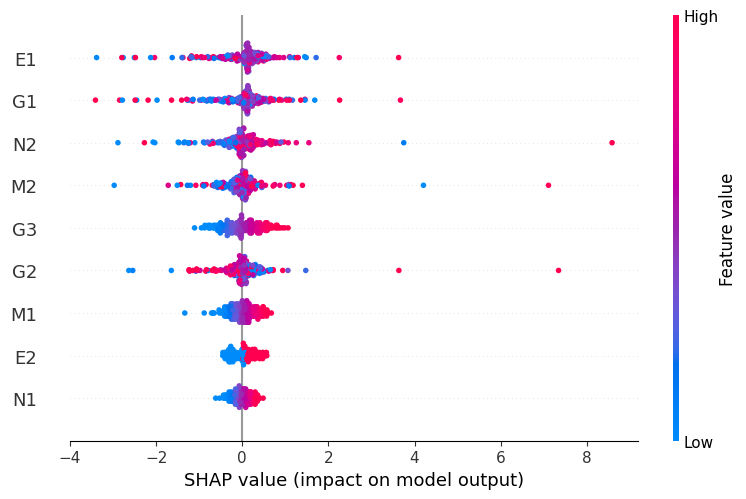

In [6]:
# --- SHAP setup ---

# Define a model prediction function for SHAP
def model_predict(X_numpy):
    X_tensor = torch.tensor(X_numpy, dtype=torch.float32)
    with torch.no_grad():
        output = wrapper(X_tensor).numpy()
    return output
X_val=ref_df.drop(columns="Unnamed: 0")

# Create SHAP KernelExplainer
explainer = shap.KernelExplainer(model_predict, X_val.values)

# Compute SHAP values
shap_values = explainer.shap_values(X_val.values)  # You can increase nsamples

# --- Plot SHAP summary ---
shap.summary_plot(shap_values[0], X_val, plot_type="dot")
shap_values=shap_values[0]

#### Clustering

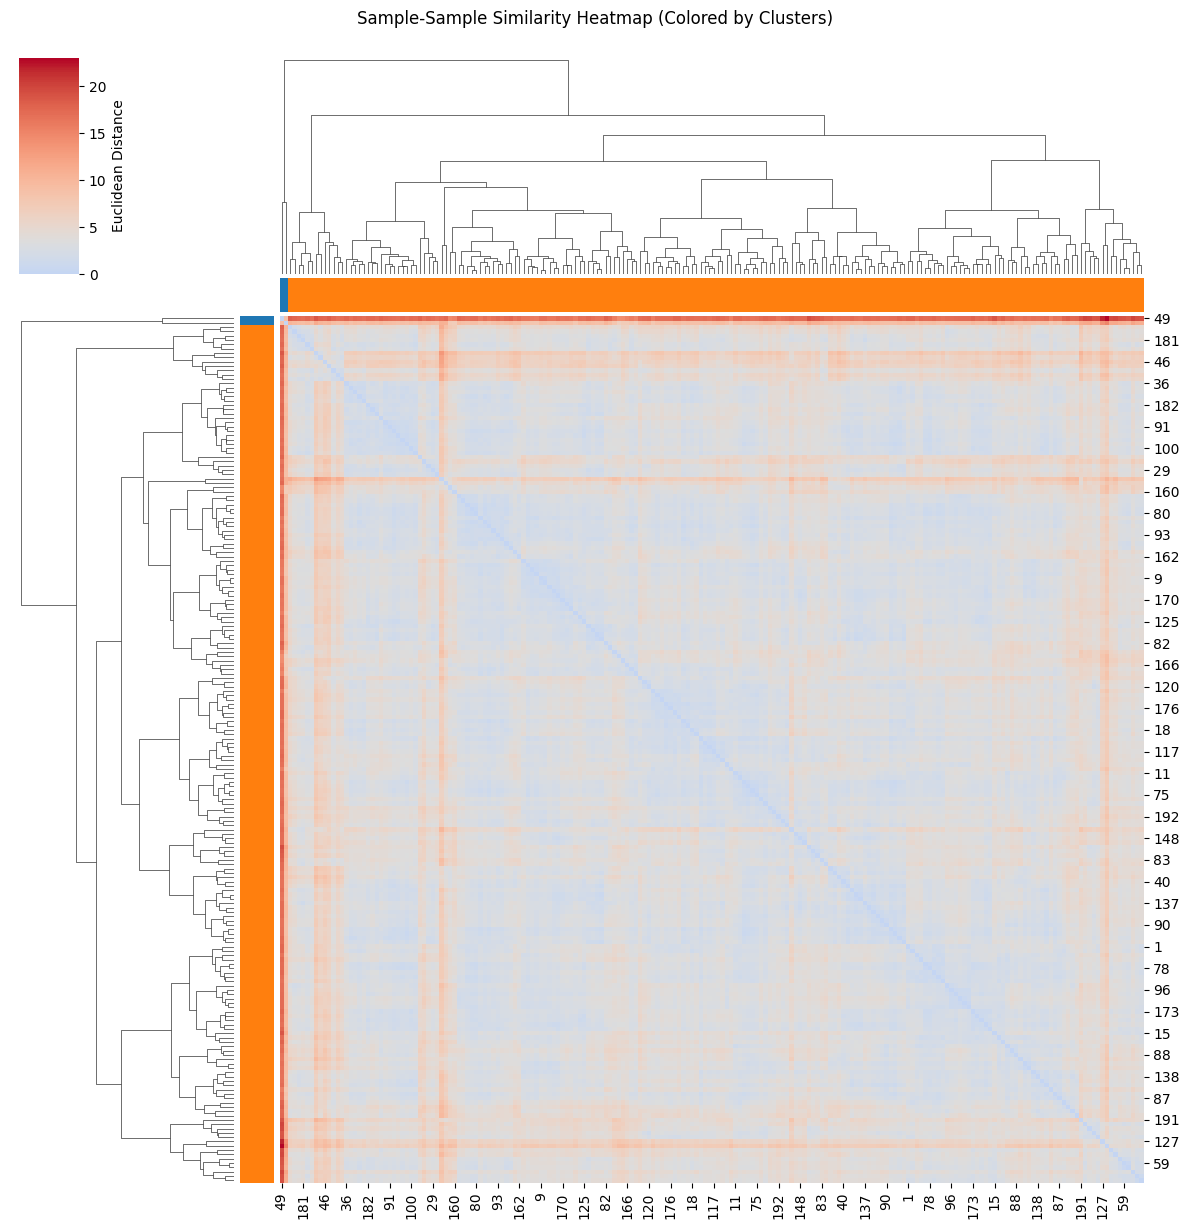

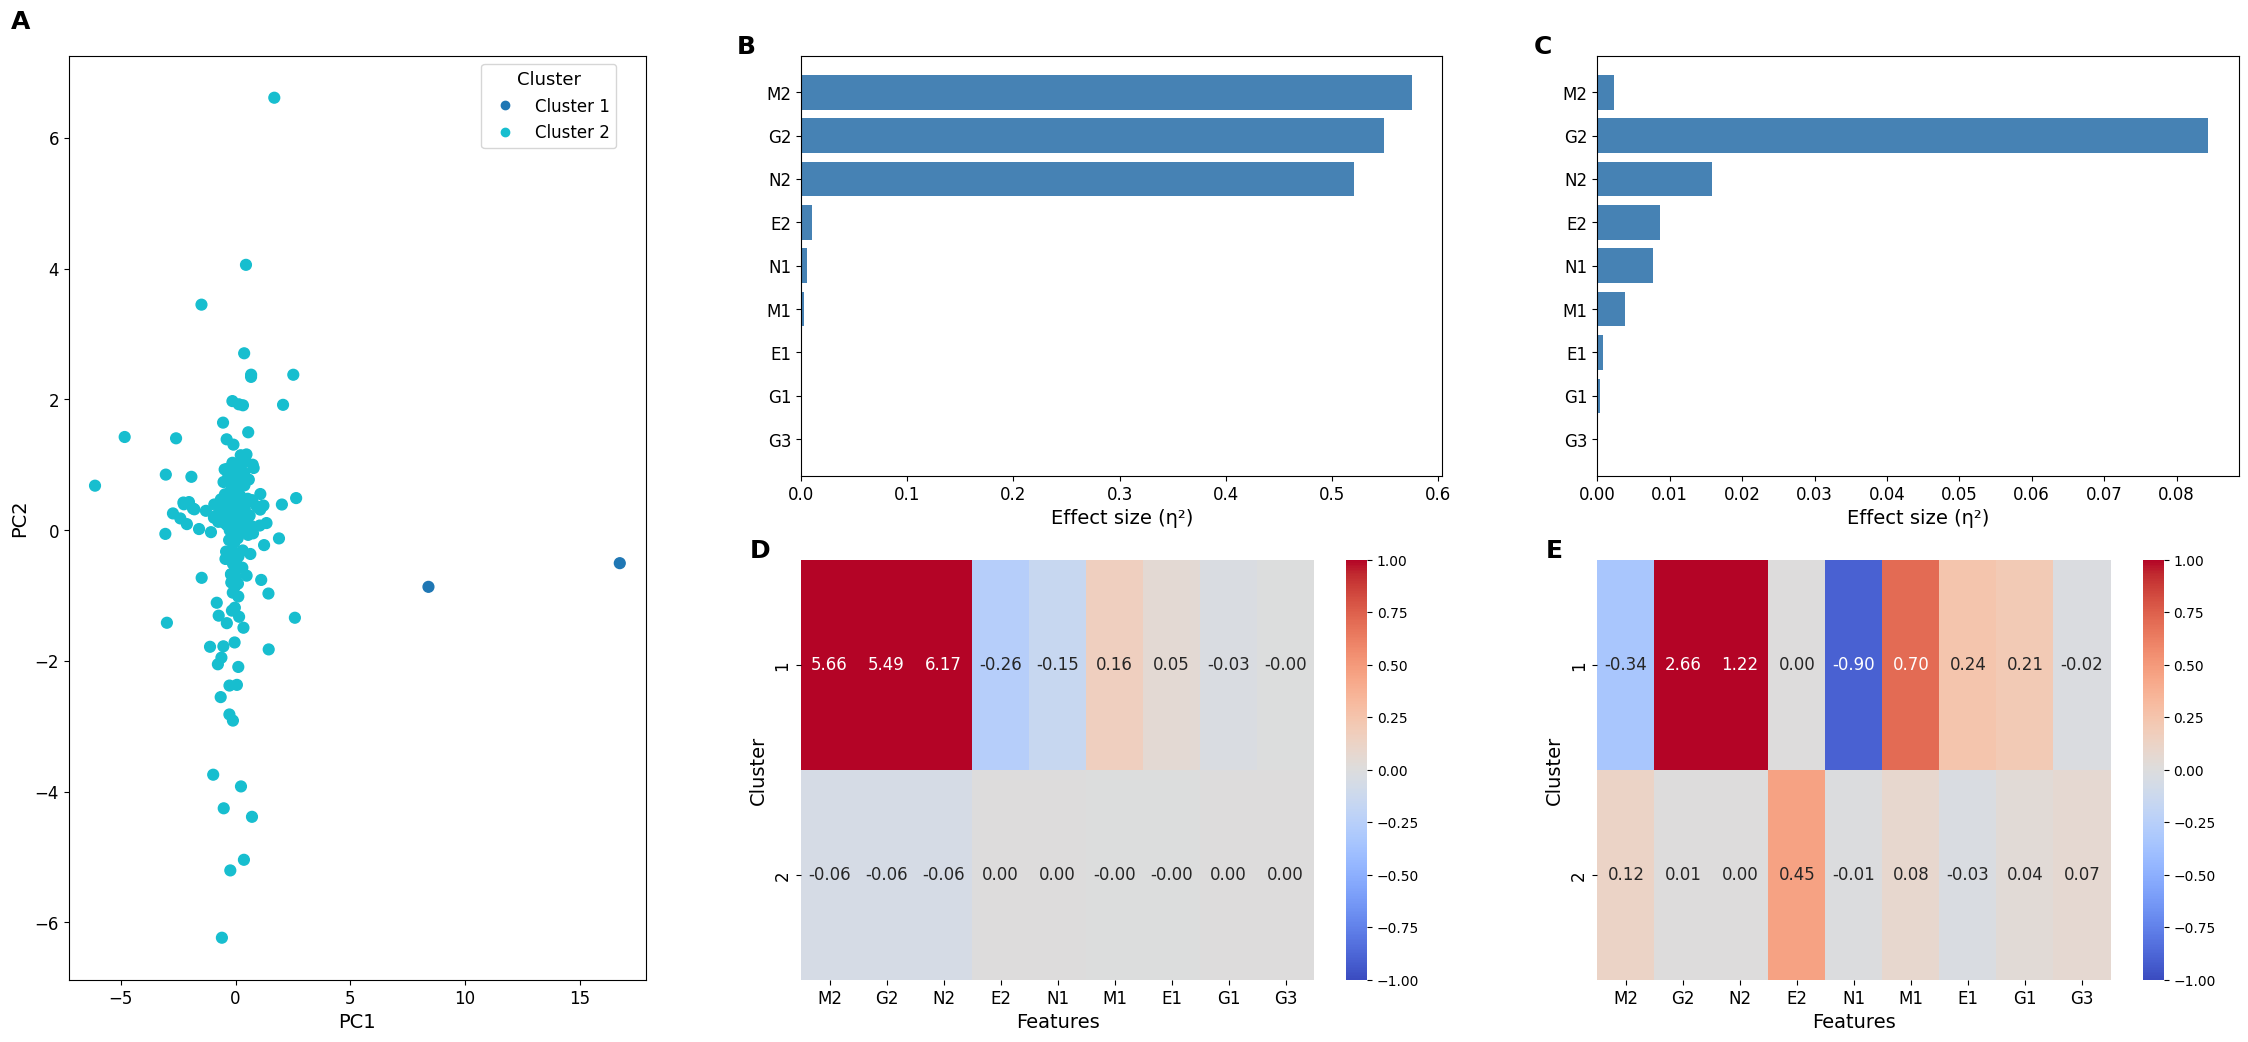

In [9]:
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.stats import f as f_dist
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif
import seaborn as sns


def shap_optimal_hclust_k(X, max_k=10, force_k=None):
    Z = linkage(X, method='ward', metric='euclidean')
    if force_k is not None:
        labels = fcluster(Z, t=force_k, criterion='maxclust')
        return force_k, labels, Z
    best_score, best_k, best_labels = -1, None, None
    for k in range(2, max_k + 1):
        labels = fcluster(Z, t=k, criterion='maxclust')
        if len(np.unique(labels)) < 2:
            continue
        score = silhouette_score(X, labels, metric='euclidean')
        print(f'k={k}: silhouette={score:.4f}')
        if score > best_score:
            best_score, best_k, best_labels = score, k, labels
    return best_k, best_labels, Z


def shap_eta2_threshold(alpha, n_samples, n_clusters):
    dfb, dfw = n_clusters - 1, n_samples - n_clusters
    if dfb <= 0 or dfw <= 0:
        return 1.0
    f_crit = f_dist.ppf(1 - alpha, dfb, dfw)
    return (f_crit * dfb) / (f_crit * dfb + dfw)


# SHAP clustering config
shap_max_k   = 10
shap_force_k = None   # silhouette-based selection (unscaled, matching tabpfn_shap2)
shap_top_n   = len(X_val.columns)

feature_names = X_val.columns.tolist()
best_k_shap, cluster_labels_shap, Z_shap = shap_optimal_hclust_k(
    shap_values, max_k=shap_max_k, force_k=shap_force_k)
print(f'Best k: {best_k_shap}')

n_clusters_shap = len(np.unique(cluster_labels_shap))
palette_shap = sns.color_palette('tab10', n_clusters_shap)
cluster_color_map = dict(zip(np.unique(cluster_labels_shap), palette_shap))
row_colors_shap = pd.Series(cluster_labels_shap).map(cluster_color_map).to_numpy()

pairwise_dist = squareform(pdist(shap_values, metric='euclidean'))
g = sns.clustermap(
    pairwise_dist,
    row_linkage=Z_shap, col_linkage=Z_shap,
    row_colors=row_colors_shap, col_colors=row_colors_shap,
    cmap='coolwarm', center=np.median(pairwise_dist),
    figsize=(10, 10), cbar_kws={'label': 'Euclidean Distance'})
g.fig.suptitle('SHAP Sample-Sample Distance (Colored by Clusters)', y=1.02)
plt.show()


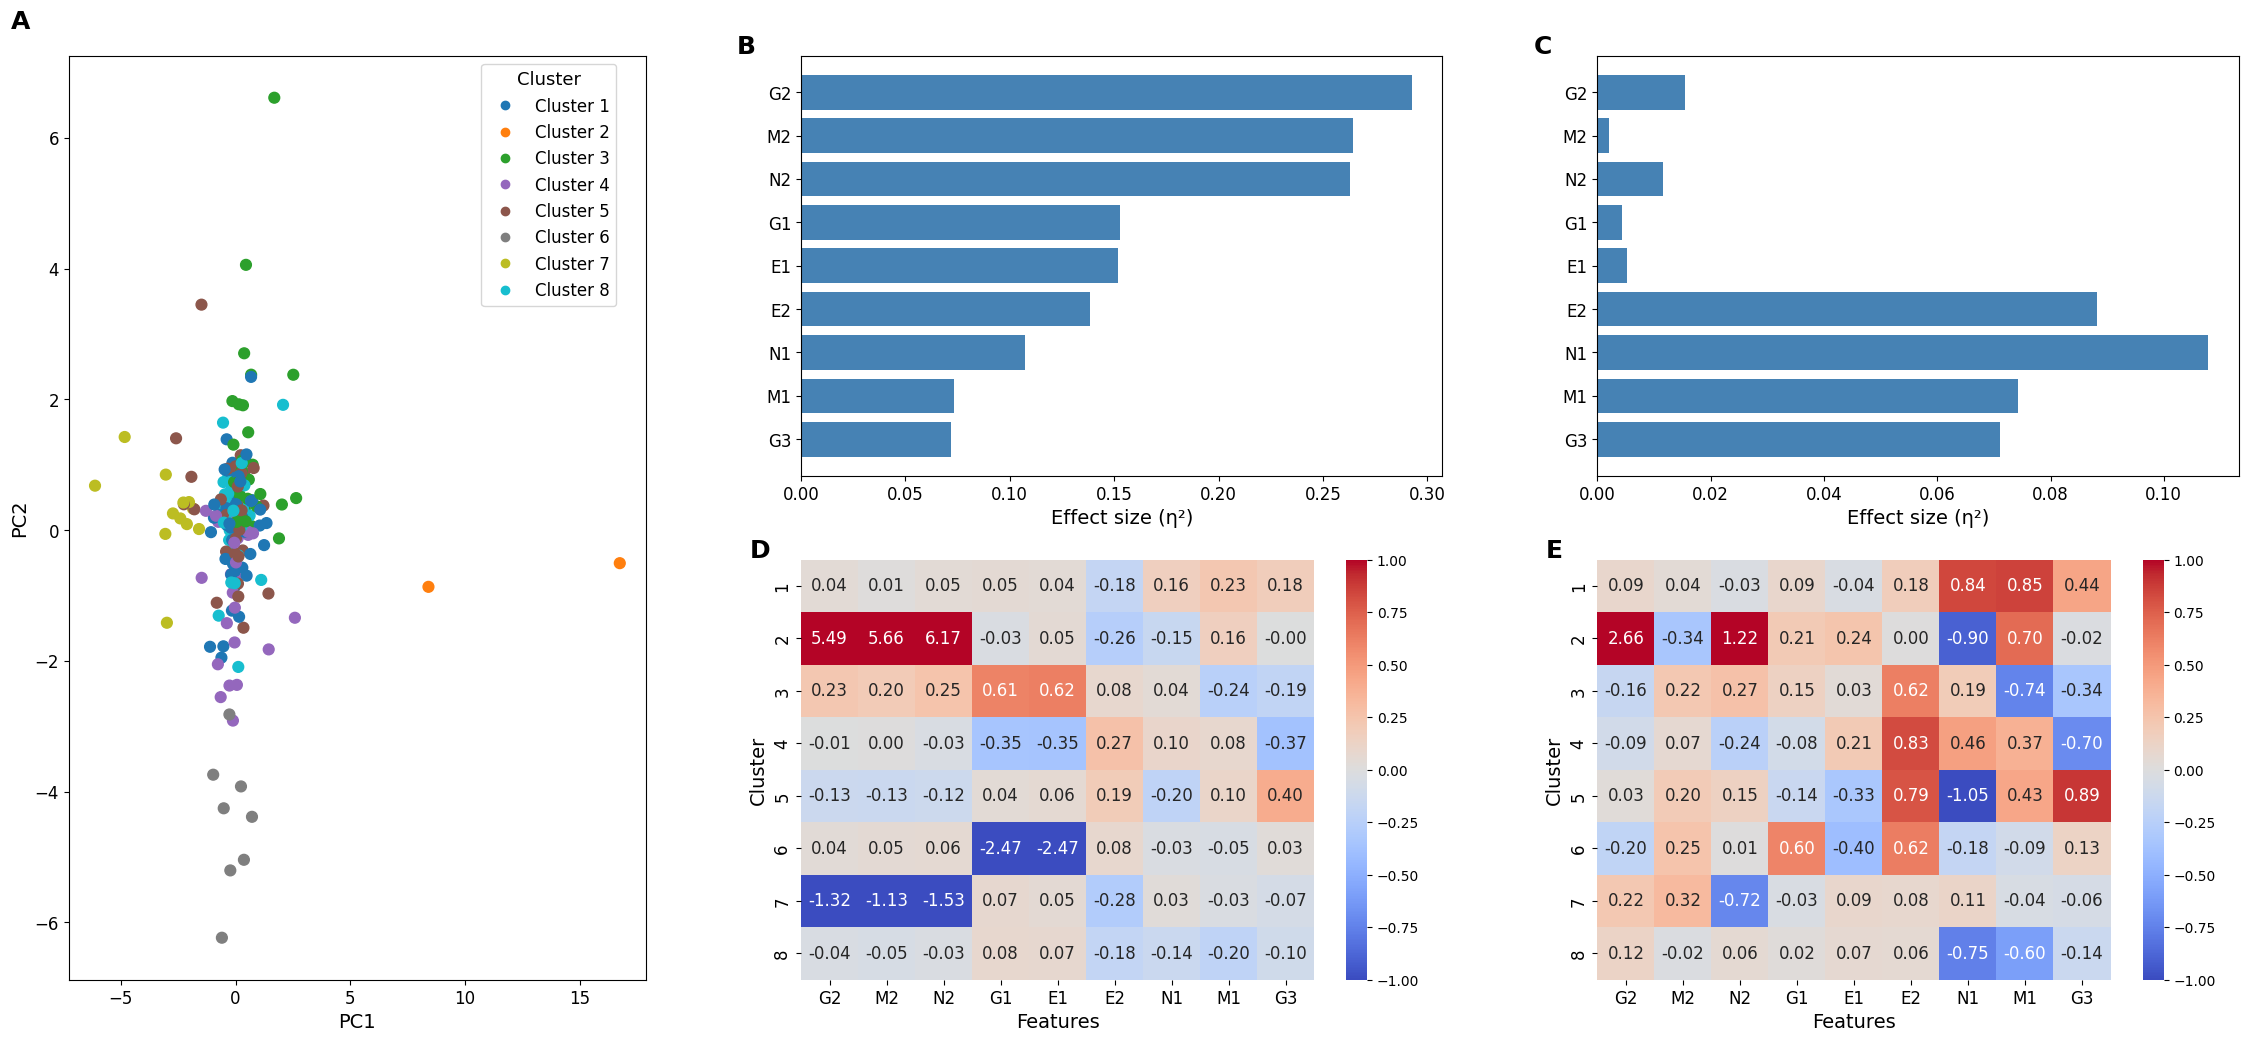

In [8]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import f_classif
from cf_search.visualize import compute_coala_cluster_metrics

# ── Ground truth ───────────────────────────────────────────────────────────────
# True interacting constraint features (drive which cluster an individual belongs to)
TRUE_CONSTRAINT = {'G1', 'G2'}
# True interacting mutable features
TRUE_MUTABLE    = {'E1', 'M2', 'N2'}

# ── Option 1: Cluster quality ──────────────────────────────────────────────────
coala_metrics = compute_coala_cluster_metrics(
    archive_data, cell_feature_sets, feature_categories,
    cluster_method=cluster_method, max_k=max_k, scale=True, reducer=reducer)
coala_summary = coala_metrics[['silhouette','davies_bouldin',
                                'calinski_harabasz','constraint_accuracy']].mean()

sil_shap = silhouette_score(shap_values, cluster_labels_shap)
db_shap  = davies_bouldin_score(shap_values, cluster_labels_shap)
ch_shap  = calinski_harabasz_score(shap_values, cluster_labels_shap)

print("Cluster quality — COALA vs SHAP:")
print(f"{'Metric':<25} {'COALA':>10} {'SHAP':>10} {'Better':>8}")
print("-" * 56)
for name, cv, sv, direction in [
    ("Silhouette",        coala_summary['silhouette'],      sil_shap, "higher"),
    ("Davies-Bouldin",    coala_summary['davies_bouldin'],  db_shap,  "lower"),
    ("Calinski-Harabasz", coala_summary['calinski_harabasz'], ch_shap, "higher"),
]:
    winner = "COALA" if (cv > sv) == (direction == "higher") else "SHAP"
    print(f"{name:<25} {cv:>10.4f} {sv:>10.4f} {winner:>8}")

# ── Option 2: Constraint predictability ───────────────────────────────────────
all_mutable     = set(f for feats in feature_categories.values() for f in feats)
constraint_cols = [c for c in X_val.columns if c not in all_mutable]
clf_shap = RandomForestClassifier(n_estimators=100, random_state=42)
shap_constraint_acc = cross_val_score(
    clf_shap, X_val[constraint_cols], cluster_labels_shap, cv=3, scoring='accuracy').mean()
print(f"\nConstraint predictability (RF accuracy):")
print(f"  COALA: {coala_summary['constraint_accuracy']:.4f}")
print(f"  SHAP:  {shap_constraint_acc:.4f}")

# ── Option 3: Ground truth recovery ───────────────────────────────────────────
# COALA: rank constraint features by mean η² across cells
eta2_per_feat = {}
for _, row_data in coala_metrics.iterrows():
    cell_key = row_data['cell']
    df_cell  = extract_cell_data(archive_data, cell_key)
    if df_cell.empty:
        continue
    mutable  = cell_feature_sets[cell_key]
    cons     = [c for c in df_cell.columns
                if c not in mutable and c not in ('cell','individual_id','fitness') and '_x_' not in c]
    if not cons:
        continue
    _, labels = optimal_clusters(df_cell[mutable].values, max_k=max_k)
    labels = labels + 1
    for feat in cons:
        x = df_cell[feat].values
        if np.var(x) < 1e-8:
            continue
        from cf_search.visualize import eta_squared_1d
        eta2_per_feat.setdefault(feat, []).append(eta_squared_1d(x, labels))

coala_eta2 = {f: np.mean(v) for f, v in eta2_per_feat.items()}
coala_ranked = sorted(coala_eta2, key=lambda f: -coala_eta2[f])

# SHAP: rank all features by η² between SHAP clusters
n_s, n_c = len(shap_values), n_clusters_shap
dfb, dfw = n_c - 1, n_s - n_c
F_shap, _ = f_classif(shap_values, cluster_labels_shap)
eta2_shap_all = (F_shap * dfb) / (F_shap * dfb + dfw)
shap_ranked_all = [feature_names[i] for i in np.argsort(-eta2_shap_all)]
shap_ranked_constraint = [f for f in shap_ranked_all if f not in all_mutable]

def precision_recall(ranked, true_set, k):
    top_k = set(ranked[:k])
    prec  = len(top_k & true_set) / k if k > 0 else 0
    rec   = len(top_k & true_set) / len(true_set) if true_set else 0
    return prec, rec

k = len(TRUE_CONSTRAINT)
p_coala, r_coala = precision_recall(coala_ranked, TRUE_CONSTRAINT, k)
p_shap,  r_shap  = precision_recall(shap_ranked_constraint, TRUE_CONSTRAINT, k)

print(f"\nGround truth recovery (top-{k} constraint features = {TRUE_CONSTRAINT}):")
print(f"{'Method':<10} {'Precision':>12} {'Recall':>10}")
print("-" * 35)
print(f"{'COALA':<10} {p_coala:>12.4f} {r_coala:>10.4f}")
print(f"{'SHAP':<10} {p_shap:>12.4f} {r_shap:>10.4f}")
print(f"\nCOALA top constraint features: {coala_ranked[:k+2]}")
print(f"SHAP  top constraint features: {shap_ranked_constraint[:k+2]}")
